# Vertical transport through a two-dimensional material

A scanning-tunnelling microscope answers one question: what does the tip *see*?
This notebook answers a different one: what gets *through*?

Put an electron in at a point above the sheet and let it leave into a metal
substrate underneath. The current is no longer set by the density of states at
the tip. It is set by the amplitude to go from the tip, through the material, to
the substrate, which is the nonlocal Green's function `G(r, r')`.

For monolayer graphene the two questions have the same answer, and the transport
map matches the tunnelling image to a correlation of **1.000000**. For a bilayer
they do not: the current has to cross both sheets, the paths interfere, and the
correlation falls to **0.16**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from defumat import Calculator

graphene = Calculator.from_file('../tests/data/qe/graphene-monolayer.in',
                                pseudo_dir='../tests/data/pseudo')

# tip plane above the sheet, substrate plane below it, atoms in between
geometry = dict(exit_height=0.38, height=0.62, shape=(24, 24),
                broadening=0.02, grid=(6, 6, 1), nbnd=20)
flow = graphene.get_vertical_transport(**geometry)
print(f'open channels through the sheet: {flow.notes["channels"]:.2f}')


[defumat] a vertical transmission: no ground state cached, running the SCF first (conv_thr = 1e-10). Call get_scf() to do this explicitly.


open channels through the sheet: 2.85


## What is being computed

In the tunnelling regime the transmission from a point tip at `r` into a plane is

$$T(\mathbf{r};E)  =  \int_{\rm plane} \bigl|G(\mathbf{r},\mathbf{r}';E)\bigr|^2\,{\rm d}^2r',
\qquad G(\mathbf{r},\mathbf{r}')  =  \sum_{n\mathbf{k}} \frac{\psi_{n\mathbf{k}}(\mathbf{r})\,\psi^{*}_{n\mathbf{k}}(\mathbf{r}')}{E-\varepsilon_{n\mathbf{k}}+i\eta}.$$

The sum over bands happens *before* the modulus is taken, which is the whole
point: different bands are different routes through the material and they add as
amplitudes, not as probabilities. `broadening` is the energy window the leads let
states through in.

Comparing against what the microscope sees at the same energy and width:


In [2]:
stm = graphene.get_stm(height=0.62, shape=(24, 24), width=0.02,
                       grid=(6, 6, 1), nbnd=20)
correlation = np.corrcoef(flow.image.ravel(), np.asarray(stm.values).ravel())[0, 1]
spread = np.abs(flow.interference).max() / flow.image.max()
print(f'graphene: correlation with the tunnelling image {correlation:.6f}')
print(f'          interference beyond the local picture {spread:.5f}')


graphene: correlation with the tunnelling image 1.000000
          interference beyond the local picture 0.00000


## Add a second layer

AB-stacked bilayer graphene is the interesting case. Its two low-energy bands are
*layer polarized*: a state that is large on the top sheet is small on the bottom
one. A microscope only ever looks at the top, so it sees the familiar picture in
which one of the two surface sublattices is bright. A current has to reach the
bottom, so it is sensitive to something the surface density of states does not
contain.


In [3]:
bilayer = Calculator.from_file('../tests/data/qe/graphene-bilayer.in',
                              pseudo_dir='../tests/data/pseudo')
stack = dict(exit_height=0.14, height=0.86, shape=(24, 24),
             broadening=0.02, grid=(6, 6, 1), nbnd=24)
flow2 = bilayer.get_vertical_transport(**stack)
stm2 = bilayer.get_stm(height=0.86, shape=(24, 24), width=0.02,
                       grid=(6, 6, 1), nbnd=24)
corr2 = np.corrcoef(flow2.image.ravel(), np.asarray(stm2.values).ravel())[0, 1]
print(f'bilayer:  correlation with the tunnelling image {corr2:.4f}')
print(f'          coherent map below the incoherent one by '
      f'{flow2.incoherent.mean()/flow2.image.mean():.0f}x')


[defumat] a vertical transmission: no ground state cached, running the SCF first (conv_thr = 1e-10). Call get_scf() to do this explicitly.


bilayer:  correlation with the tunnelling image 0.1562
          coherent map below the incoherent one by 26x


## The two pictures, side by side


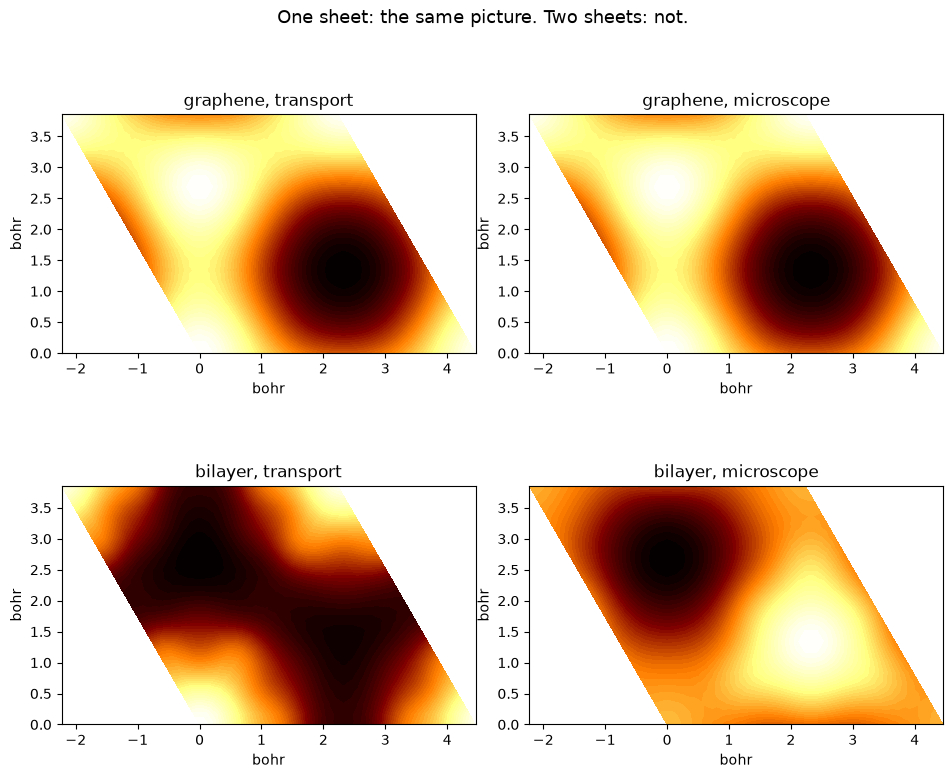

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(9.5, 8.2))
panels = [(flow, 'graphene, transport'), (stm, 'graphene, microscope'),
          (flow2, 'bilayer, transport'), (stm2, 'bilayer, microscope')]
for a, (obj, title) in zip(ax.ravel(), panels):
    field = obj.image if hasattr(obj, 'interference') else np.asarray(obj.values)
    xy = obj.coordinates.reshape(-1, 2)
    a.tricontourf(xy[:, 0], xy[:, 1], field.ravel() / field.max(),
                  60, cmap='afmhot')
    a.set(title=title, xlabel='bohr', ylabel='bohr', aspect='equal')
fig.suptitle('One sheet: the same picture. Two sheets: not.', fontsize=13)
fig.tight_layout()


## What separates them

The substrate is an infinite featureless plane, so it is unchanged by every
lateral translation of the lattice. That conserves the electron's in-plane
momentum on the way out, which means routes at different `k` cannot interfere
with each other, and routes at the *same* `k` can.

Graphene's states at the Fermi level are the two Dirac states at each corner of
the Brillouin zone, and they are degenerate partners of one another. The symmetry
of that corner forces the substrate to couple to the two equally and separately,
so there is nothing for them to interfere through and the transmission collapses
back to the local density of states at the tip. The bilayer's low-energy states
are related by no such symmetry, they sit on different layers, and they cancel.
The number of independent ways through, below, is the direct measure of that.


In [5]:
rows = [('graphene', flow, correlation), ('bilayer', flow2, corr2)]
print(f'{"":10s} {"channels":>9s} {"correlation":>12s}'
      f' {"incoherent/coherent":>20s}')
for name, t, c in rows:
    print(f'{name:10s} {t.notes["channels"]:9.2f} {c:12.4f}'
          f' {t.incoherent.mean()/t.image.mean():20.1f}')


            channels  correlation  incoherent/coherent
graphene        2.85       1.0000                  1.0
bilayer         1.93       0.1562                 26.4


## Two magnets, one junction

Nothing so far has cared which way an electron's spin points. Make both
electrodes magnetic and it becomes the whole answer. A magnetic tip counts the
electrons whose spin lies along its own moment, a magnetic substrate accepts the
ones whose spin lies along its, and the sheet in between carries a moment of its
own that the current has to pass through on the way.

That is a spin valve. Each electrode counts spins along a single direction, so
the transmission is **linear** in the tip's moment: three tip directions fix the
current for every other one. The curve below is drawn from three of the thirteen
points, and the other ten land on it.

Where that curve peaks is not where either electrode points. The sheet between
them has a moment of its own, lying in the plane and turned away from the
substrate's, and what the junction favours is set by all three together. The
swing between the largest and smallest current is the tunnelling
magnetoresistance, which is what a spin-polarized microscope reads off a magnetic
surface.

The sheet below is a square lattice of hydrogen and both electrodes are 90 per
cent polarized. `spin` sets the substrate's moment and `tip_spin` the tip's.

In [6]:
magnet = Calculator.from_file('../tests/data/qe/h-sheet-noncolin.in',
                              pseudo_dir='../tests/data/pseudo')

# the substrate's moment held along x, the tip's turned through the plane
junction = dict(exit_height=0.15, height=0.85, shape=(20, 20),
                broadening=0.05, spin=(1.0, 0.0, 0.0), polarization=0.9)
angles = np.linspace(0.0, 360.0, 13)
current = np.array([
    magnet.get_vertical_transport(
        tip_spin=(np.cos(np.radians(a)), np.sin(np.radians(a)), 0.0),
        tip_polarization=0.9, **junction).image.mean()
    for a in angles])

print(f'antiparallel / parallel current: {current[6] / current[0]:.2f}')

[defumat] a vertical transmission: no ground state cached, running the SCF first (conv_thr = 1e-10). Call get_scf() to do this explicitly.


antiparallel / parallel current: 5.31


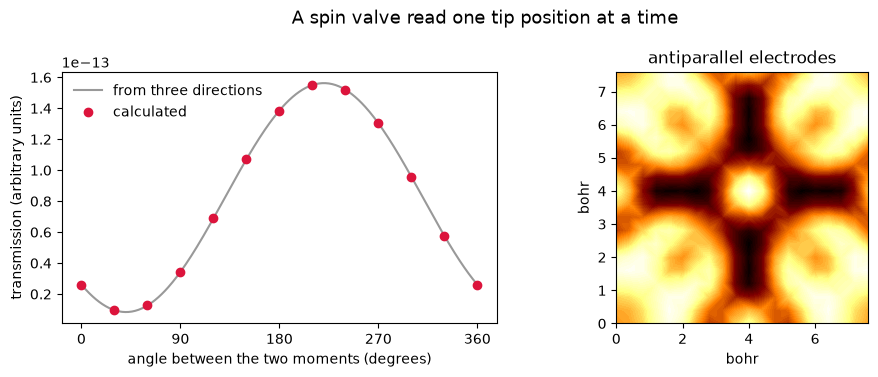

In [7]:
antiparallel = magnet.get_vertical_transport(
    tip_spin=(-1.0, 0.0, 0.0), tip_polarization=0.9, **junction)

# three tip directions fix the whole curve, the current being linear in the
# tip's moment: the transmission at 0, 90 and 180 degrees
c0 = 0.5 * (current[0] + current[6])
cx, cy = 0.5 * (current[0] - current[6]), current[3] - c0
fine = np.radians(np.linspace(0.0, 360.0, 361))

fig, ax = plt.subplots(1, 2, figsize=(9.8, 3.8))
ax[0].plot(np.degrees(fine), c0 + cx * np.cos(fine) + cy * np.sin(fine), '-',
           color='0.6', label='from three directions')
ax[0].plot(angles, current, 'o', color='crimson', label='calculated')
ax[0].set(xlabel='angle between the two moments (degrees)',
          ylabel='transmission (arbitrary units)', xticks=[0, 90, 180, 270, 360])
ax[0].legend(frameon=False)
xy = antiparallel.coordinates.reshape(-1, 2)
field = antiparallel.image
ax[1].tricontourf(xy[:, 0], xy[:, 1], field.ravel() / field.max(), 60,
                  cmap='afmhot')
ax[1].set(title='antiparallel electrodes', xlabel='bohr', ylabel='bohr',
          aspect='equal')
fig.suptitle('A spin valve read one tip position at a time', fontsize=13)
fig.tight_layout()

## Reading the map

`flow.image` is proportional to a conductance, not equal to one: how strongly the
tip and the substrate couple to the sheet are two constants this does not know.
What is meaningful is the map, its contrast, and how it changes with the tip
energy, all of which are exactly what an experiment varies.

`flow.interference` is the part of the map that no local picture can produce, that
is, the difference between letting the bands add as amplitudes and adding them one
at a time. It is zero for graphene and it is most of the answer for the bilayer.

Passing `energies=` sweeps the tip energy and costs almost nothing extra, since
where the wavefunctions sit does not depend on it. `spin=` gives a magnetic
substrate and `tip_spin=` a magnetic tip, each counting only the electrons whose
spin points along its own moment, and either may be used without the other.

---

The checks behind this notebook are in `tests/regression/test_transport.py` and
`tests/unit/test_transport_machinery.py`.
